# V3 moneyness performance — 1.5-year fixed calibration

**This notebook is the computational source of truth.** The matching PDF is written from the same payload.

This report classifies the **same** option contracts as `V4_1p5y_fixed_empirical_study` into DOTM / OTM / ATM / ITM / DITM. It does not change filters, calibration, contracts, LSM settings, or the market benchmark.

| Item | Setting |
|------|---------|
| Models | GBM, Modified GBM, GARCH, Heston, Merton, GARCH–Merton, Heston–Merton |
| Companies | SPY, AAPL, MSFT, AMZN (pooled in both analyses) |
| Regimes | Crisis, Normal, Late-cycle, COVID (pooled in Analysis 1; separate in Analysis 2) |
| Contracts | Monday nearest-ATM listed calls from the main study (`n = 802` per model) |
| Moneyness | `m = S/K` (calls) |
| Primary metric | RMSE% |
| Secondary | MAE, Bias $, **Bias%**, Early-exercise fraction |


## 0. Methodology

### Same design as the main study
1.5-year lookback, `none` recalibration, V3 filters (no-arbitrage, DTE 7–60, |S/K−1|≤10%, liquidity), Euler-corrected Heston, option-implied Heston NLS, LSM with 10,000 paths and seed 42. No look-ahead.

### Moneyness rule (calls)
Let `m = S/K`.

| Bucket | Rule |
|--------|------|
| DOTM | m < 0.98 |
| OTM | 0.98 ≤ m < 0.995 |
| ATM | 0.995 ≤ m ≤ 1.005 |
| ITM | 1.005 < m ≤ 1.02 |
| DITM | m > 1.02 |

These five bins partition the main-study 10% moneyness filter. The Monday ATM sampler concentrates mass in ATM.

### Metrics
- RMSE% = 100 × √ mean(((model − market)/market)²)
- Bias $ = mean(model − market)
- Bias% = 100 × mean((model − market)/market)
- BEST = lowest RMSE% among models with n > 0


In [1]:
import sys
from pathlib import Path
from IPython.display import display, HTML
ROOT = Path.cwd()
for cand in [ROOT, *ROOT.parents]:
    scripts = cand / 'V4-Models_result' / 'scripts'
    if scripts.exists():
        sys.path.insert(0, str(scripts))
        break
import run_v4_1p5y_10k_fixed_moneyness_study as mx
panel = mx.load_panel()
payload = mx.build_payload(panel)
pdf = mx.write_pdf(payload)
print('n_overall', payload['n_overall'])
print('PDF', pdf)

## 1. Shared sample counts


In [1]:
display(HTML('counts'))

Regime,DOTM,OTM,ATM,ITM,DITM,Total
2008-2009,18,43,80,43,16,200
2013-2014,0,5,192,3,0,200
2018-2019,0,4,191,7,0,202
2019-2020,0,6,189,5,0,200
All,18,58,652,58,16,802


## 2. Analysis 1 — Overall moneyness


### Table M1. DOTM  ·  m < 0.98  ·  n = 18  ·  **BEST = Merton**


In [1]:
tab = payload['analysis1']['DOTM']
rows, header, best = mx._model_rows(tab['rows'])
display(HTML(mx._html_rows(rows, header, best)))

Model,n,RMSE%,MAE,Bias $,Bias%,Early-ex.,Rank
GBM,18,34.14,1.2323,-0.4208,-3.15,18.8%,6
Modified GBM,18,33.14,1.2868,-0.7616,-11.27,19.8%,4
GARCH,18,33.76,1.2330,-0.4053,-0.45,18.6%,5
Heston,18,30.92,1.2195,-0.8021,-12.12,15.1%,3
Merton,18,30.69,1.1924,-0.6232,-8.16,12.2%,1
GARCH–Merton,18,53.89,1.4954,+0.6023,+25.64,14.1%,7
Heston–Merton,18,30.77,1.2060,-0.6403,-8.44,9.1%,2


### Table M2. OTM  ·  0.98 ≤ m < 0.995  ·  n = 58  ·  **BEST = Merton**


In [1]:
tab = payload['analysis1']['OTM']
rows, header, best = mx._model_rows(tab['rows'])
display(HTML(mx._html_rows(rows, header, best)))

Model,n,RMSE%,MAE,Bias $,Bias%,Early-ex.,Rank
GBM,58,43.05,1.2320,-0.0840,+5.78,21.7%,5
Modified GBM,58,40.29,1.1889,-0.3358,+0.62,22.7%,2
GARCH,58,41.78,1.1965,-0.0659,+10.40,20.3%,3
Heston,58,42.66,1.1901,-0.2036,+4.98,15.8%,4
Merton,58,40.28,1.1820,-0.1032,+5.58,17.2%,1
GARCH–Merton,58,59.12,1.4946,+0.6796,+31.70,16.0%,7
Heston–Merton,58,45.60,1.2180,+0.0719,+11.01,11.2%,6


### Table M3. ATM  ·  0.995 ≤ m ≤ 1.005  ·  n = 652  ·  **BEST = GARCH**


In [1]:
tab = payload['analysis1']['ATM']
rows, header, best = mx._model_rows(tab['rows'])
display(HTML(mx._html_rows(rows, header, best)))

Model,n,RMSE%,MAE,Bias $,Bias%,Early-ex.,Rank
GBM,652,41.64,4.4486,+0.8708,+14.16,24.0%,4
Modified GBM,652,41.49,4.5182,+1.1699,+12.76,24.5%,3
GARCH,652,38.49,4.0841,-0.6047,+10.28,22.4%,1
Heston,652,44.79,4.5911,+0.8212,+19.18,17.4%,5
Merton,652,41.46,4.5326,+0.8942,+14.34,18.8%,2
GARCH–Merton,652,51.30,4.6488,+1.5259,+26.29,18.4%,6
Heston–Merton,652,56.15,5.8676,+3.5368,+35.03,11.8%,7


### Table M4. ITM  ·  1.005 < m ≤ 1.02  ·  n = 58  ·  **BEST = GARCH**


In [1]:
tab = payload['analysis1']['ITM']
rows, header, best = mx._model_rows(tab['rows'])
display(HTML(mx._html_rows(rows, header, best)))

Model,n,RMSE%,MAE,Bias $,Bias%,Early-ex.,Rank
GBM,58,28.03,1.0069,-0.4877,-10.20,27.6%,3
Modified GBM,58,28.24,0.9858,-0.6538,-12.90,28.7%,4
GARCH,58,27.17,0.9648,-0.4008,-3.60,25.6%,1
Heston,58,28.72,1.0304,-0.5118,-9.09,21.3%,5
Merton,58,27.33,1.0220,-0.3921,-6.74,20.3%,2
GARCH–Merton,58,32.59,1.1342,+0.2247,+10.23,20.0%,7
Heston–Merton,58,29.45,1.0780,-0.1324,-1.56,13.5%,6


### Table M5. DITM  ·  m > 1.02  ·  n = 16  ·  **BEST = Heston**


In [1]:
tab = payload['analysis1']['DITM']
rows, header, best = mx._model_rows(tab['rows'])
display(HTML(mx._html_rows(rows, header, best)))

Model,n,RMSE%,MAE,Bias $,Bias%,Early-ex.,Rank
GBM,16,25.04,1.2933,-0.3293,-3.90,29.2%,5
Modified GBM,16,24.31,1.2710,-0.6582,-9.33,30.8%,4
GARCH,16,25.66,1.3065,-0.2992,-0.57,27.2%,6
Heston,16,23.68,1.2301,-0.7548,-10.55,22.0%,1
Merton,16,23.80,1.2447,-0.4629,-4.98,24.5%,2
GARCH–Merton,16,37.87,1.4533,+0.7255,+18.85,20.8%,7
Heston–Merton,16,23.95,1.2472,-0.3542,-2.80,13.3%,3


### Figure M1 — Model × Moneyness RMSE% heatmap


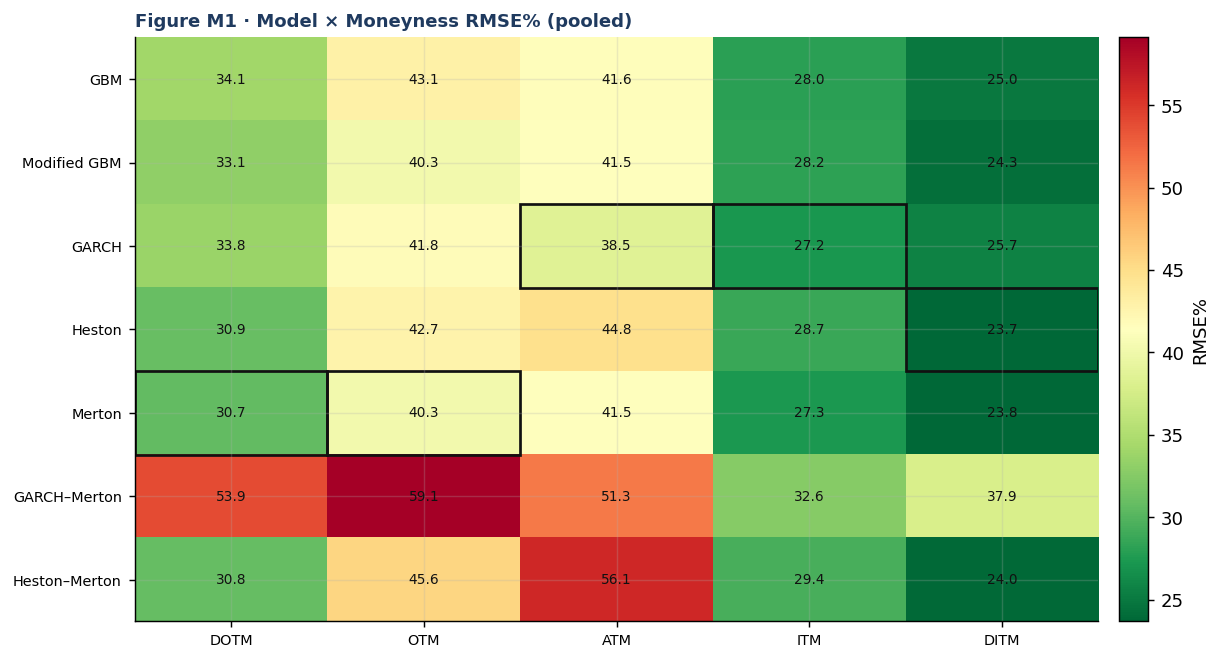

In [1]:
pass

## 3. Analysis 2 — Regime × moneyness


### Figure M2 — RMSE% heatmaps by regime


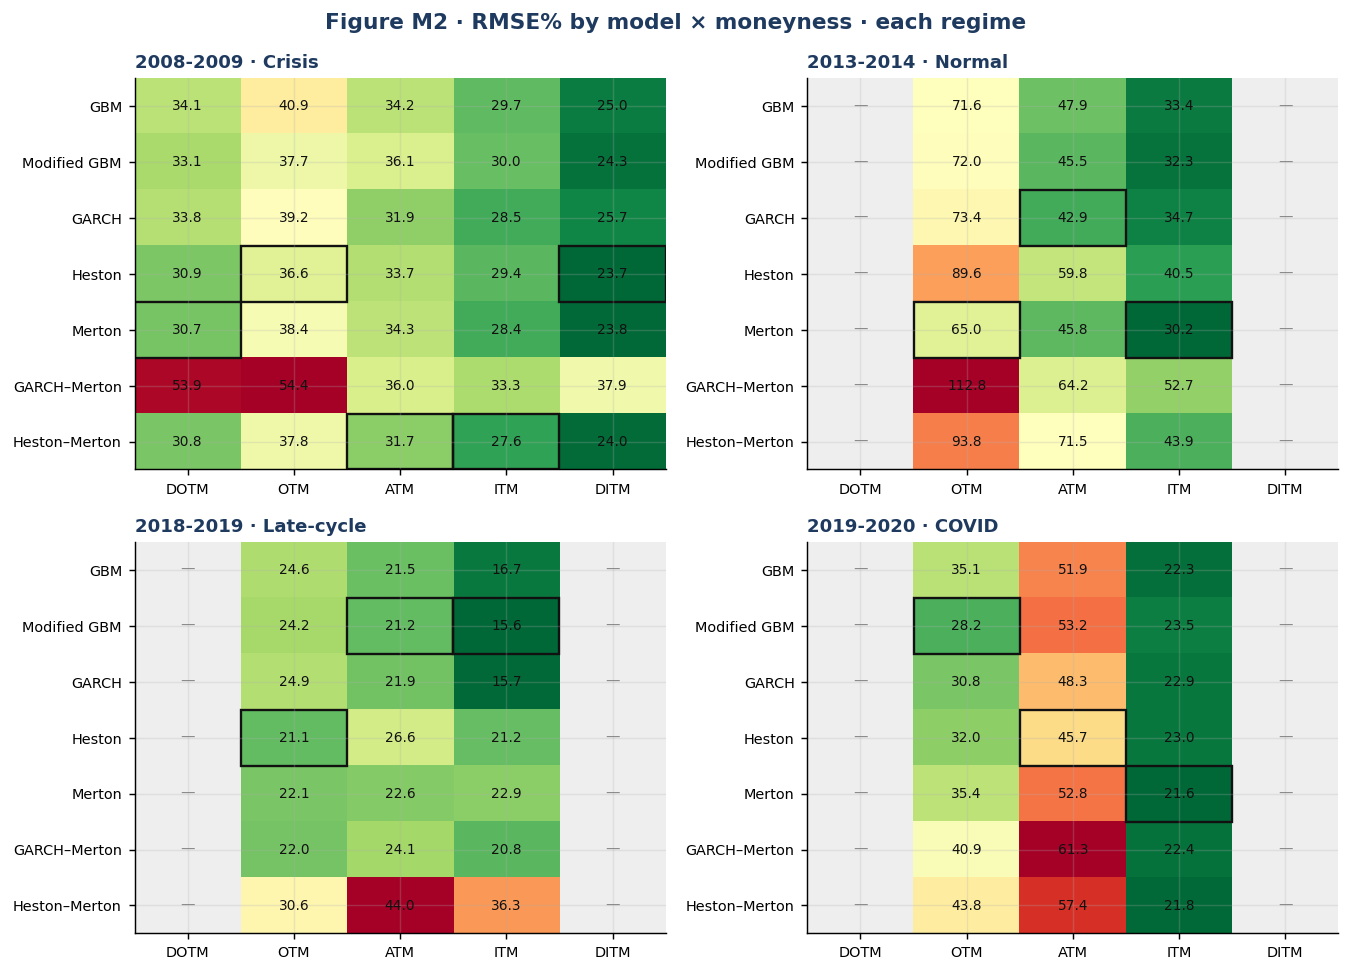

In [1]:
pass

### Table M6 — Best model by regime × moneyness


In [1]:
display(HTML('m6'))

Regime,DOTM,OTM,ATM,ITM,DITM
2008-2009,Merton,Heston,Heston–Merton,Heston–Merton,Heston
2013-2014,—,Merton,GARCH,Merton,—
2018-2019,—,Heston,Modified GBM,Modified GBM,—
2019-2020,—,Modified GBM,Heston,Merton,—


### Table M7 — n by regime × moneyness


In [1]:
display(HTML('m7'))

Regime,DOTM,OTM,ATM,ITM,DITM
2008-2009,18,43,80,43,16
2013-2014,0,5,192,3,0
2018-2019,0,4,191,7,0
2019-2020,0,6,189,5,0


## 4. Findings

- DOTM (n = 18): BEST = Merton with RMSE% = 30.69, Bias% = -8.16.

- OTM (n = 58): BEST = Merton with RMSE% = 40.28, Bias% = +5.58.

- ATM (n = 652): BEST = GARCH with RMSE% = 38.49, Bias% = +10.28.

- ITM (n = 58): BEST = GARCH with RMSE% = 27.17, Bias% = -3.60.

- DITM (n = 16): BEST = Heston with RMSE% = 23.68, Bias% = -10.55.

- Overall, the ranking does change with moneyness: DOTM → Merton, OTM → Merton, ATM → GARCH, ITM → GARCH, DITM → Heston.

- Inside regimes, the BEST model also changes with moneyness in: 2008-2009, 2013-2014, 2018-2019, 2019-2020.

- These comparisons use the Monday nearest-ATM sample, so ATM is the only well-populated bucket after 2009. DOTM/DITM results rest on few 2008–2009 quotes and should be read as descriptive, not as a high-powered test.


## 5. Re-run

```python
import run_v4_1p5y_10k_fixed_moneyness_study as mx
payload = mx.run()
```

Requires the main study contract CSVs under `V4-Models_result/results/empirical_study_1p5y_fixed_10000/contracts/`.
